# FRB cosmology constrain from $DM_{IGM} $

Highly uncertain: $\Omega_b, f_{IGM}, \chi, \omega$ (If do wCDM cosmology)

For FRB, cosmology distance is based on the dispersion measure (DM), which defined as
$$ DM=\int_0^{D_z}\frac{n_e(l)}{1+z(l)}dl $$

DM can be splitted into multiple terms:
$$ DM=DM_{MW}+DM_{halo}+DM_{IGM}+\frac{DM_{host}+DM_{src}}{1+z}$$
where $DM_{MW}$ is the DM from the Milky Way, $DM_{halo}$ is the DM from the halo, $DM_{IGM}$ is the DM from the intergalactic medium, $DM_{host}$ is the DM from the host galaxy, and $DM_{src}$ is the DM from the source.

$DM_{MW}$ can be derived from model. $DM_{halo} \sim (30-80)pc \; cm^{-3}$

Most important is the IGM component:
$$ <DM_{IGM}>=\frac{3cH_0 \Omega_b }{8\pi G m_p}\int_0^z \frac{f_{IGM}\Chi(z')(1+z')dz'}{E(z')}$$
Here,
$$\Chi=Y_H X_{e,H}+\frac{1}{2}Y_{He} X_{e,He}$$
Recall $Y_H=1/4$ and $Y_{He}=3/4$.

According to [[Bei Zhou 2014](https://journals.aps.org/prd/abstract/10.1103/PhysRevD.89.107303)], $z\lesssim 3$, $X_{e,H}=X_{e,He}=1$; at $z\gtrsim 1.5$ $f_{IGM}\approx 90\%$; as $z\leq 0.4$ $f_{IGM}\approx (82\pm 4)\%$

H fully ionized ($\chi_{e,H}=1)$ at $ z<6 $ ([Fan 2006](https://www.annualreviews.org/content/journals/10.1146/annurev.astro.44.051905.092514)), He fully ionized ($\chi_{e,He}=1$) at $ z<2$ ([McQuinn 2009](https://ui.adsabs.harvard.edu/abs/2009ApJ...694..842M/abstract))

In [1]:
import sys
sys.path.append('../Python_scripts')
from config import *
from support import *
from cosmo_support import *

In [2]:
# From DM derive redshift. Previous project analyze code.
# from scipy import integrate

# def f_IGM(z):
#     #0.84
#     return (z>1.5)*0.9+(z<=1.5)*(0.053*z+0.82) #0.83 #according to Bei Zhou 2014 paper

# def I_IGM(z,m=O_m,la=O_L):
#     return (1.+z)*f_IGM(z)/np.sqrt(m*(1.+z)**3+la)

# def f_DM(z,a=alpha):
#     Int=integrate.quad(I_IGM,0,z)[0]
#     return 30.0+a*Int+70.0/(1.+z)

# from scipy.optimize import fsolve
# def f_z(DM_MW,n=8):
#     ''' z1=0
#     z2=3
#     E=z2-z1
#     error=1/pow(10,n)
#     while E>=error/2:
#         #print([f_DM(z1),f_DM(z2)])
#         zt=(z1+z2)/2
#         ft=f_DM(zt)-DM_MW
        
#         if(ft<0):
#             z1=zt
#         elif(ft>0):
#             z2=zt
#         else:
#             z=zt
#             break
        
#         E=z2-z1
#         z=round((z1+z2)/2,n)
#         #if(z==0):
#         #    z=0.01 '''
#     return fsolve(lambda z:f_DM(z)-DM_MW,0)[0]

# load the FRB data

In [3]:
df1 = pd.read_csv('FRB_Surajit.csv')
df1['DM_ext']=df1['DM_obs (pc cm^-3)']-df1['DM_MW (pc cm^-3)']
df1.head()

,FRB,DM_obs (pc cm^-3),E_DM_obs,DM_MW (pc cm^-3),z,DM_ext
0,FRB 20121102A,557.00,2.00,188.0,0.19273,369.00
1,FRB 20171020A,114.10,0.20,38.0,0.00860,76.10
2,FRB 20180301A,522.00,0.20,152.0,0.33040,370.00
3,FRB 20180916B,349.30,0.20,200.0,0.03370,149.30
4,FRB 20180924B,361.42,0.06,40.5,0.32140,320.92


In [4]:
df2 = pd.read_excel('FRB_Kritti.xlsx')
df2['FRB']='FRB '+df2['FRB']
df2.head()

,FRB,RA,Decl,z,E_z,DM_ext
0,FRB 20220319D,02:08:42.70,+71:02:06.94,0.0112,0.0001,-22
1,FRB 20231120A,09:35:56.15,+73:17:04.80,0.0368,0.0001,395
2,FRB 20220207C,20:40:47.89,+72:52:56.38,0.0433,0.0001,182
3,FRB 20220509G,18:50:40.80,+70:14:37.80,0.0894,0.0001,214
4,FRB 20230124A,15:27:39.9,+70:58:05.20,0.0939,0.0002,551


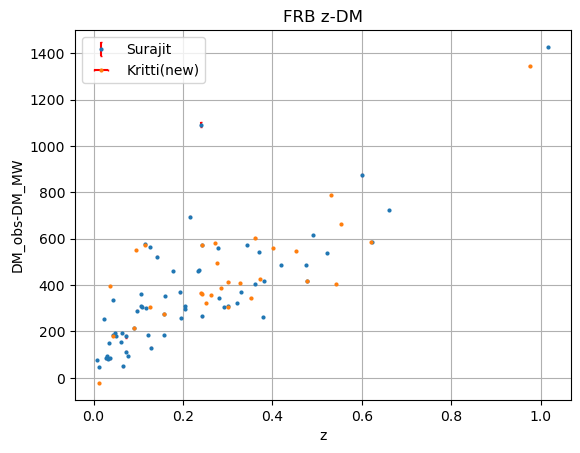

In [5]:
plt.errorbar(df1['z'], df1['DM_ext'], yerr=df1['E_DM_obs'], fmt='o', ecolor='red', capsize=1, label='Surajit',markersize=2)
plt.errorbar(df2['z'], df2['DM_ext'], xerr=df2['E_z'], fmt='o', ecolor='red', capsize=1, label='Kritti(new)',markersize=2)
plt.xlabel('z')
plt.ylabel('DM_obs-DM_MW')
plt.title('FRB z-DM')
plt.legend()
plt.grid(True)
plt.show()

combine data sets

df1 have E_DM, df2 have E_z

In [6]:
print(len(df1)+len(df2))
data=df1[['FRB','DM_ext','z']]
data=pd.concat([data,df2[['FRB','DM_ext','z']]],ignore_index=True)
data = data[data['FRB'] != 'FRB 20190520B']
print(len(data))
data.head()

93
92


,FRB,DM_ext,z
0,FRB 20121102A,369.00,0.19273
1,FRB 20171020A,76.10,0.00860
2,FRB 20180301A,370.00,0.33040
3,FRB 20180916B,149.30,0.03370
4,FRB 20180924B,320.92,0.32140


In [7]:
# Assuming your dataframe is named df
# 1. Find rows where DM_ext < 0
dropped_rows = data[data['DM_ext'] < 0]

# 2. Print FRB values of dropped rows if any exist
if not dropped_rows.empty:
    print("Dropped rows:")
    print(dropped_rows[['FRB', 'DM_ext']])
else:
    print("No rows with DM_ext < 0 found to drop")

# 3. Keep only rows where DM_ext >= 0
data = data[data['DM_ext'] >= 0]

print(f'Now there are {len(data)} rows in the dataframe')

Dropped rows:
              FRB  DM_ext
63  FRB 20220319D   -22.0
Now there are 91 rows in the dataframe


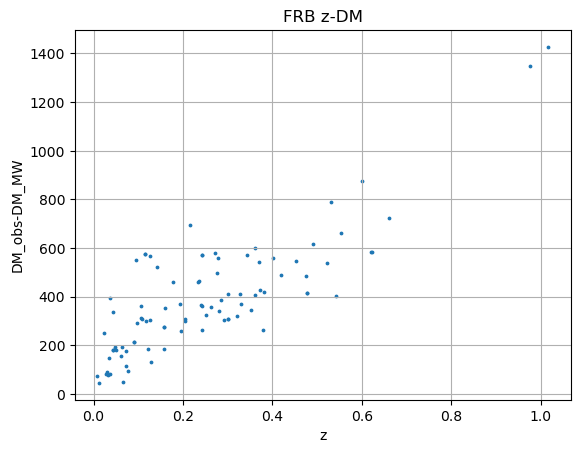

In [8]:
plt.scatter(data['z'],data['DM_ext'],s=3)  
plt.xlabel('z')
plt.ylabel('DM_obs-DM_MW')
plt.title('FRB z-DM')
plt.grid(True)
plt.show()

## The simplest case: $\chi^2$ with a single DM parameter

- For the dispersion measure:

We have contributions from the MW ${\rm DM}_{\rm MW}$, the observational limitations ${\rm DM}_{\rm obs}$, the intergalactic medium ${\rm DM}_{\rm IGM}$, the host galaxy ${\rm DM}_{\rm host}$ and potentially the source itself ${\rm DM}_{\rm host}$. Some fiducial values based on [[arXiv:1805.12265](https://arxiv.org/abs/1805.12265)] are [in pc/cm$^3$]:

$$
\sigma_{\rm MW} \sim 10, \quad \sigma_{\rm obs} \sim 1.5, \quad \sigma_{\rm IGM} \sim 100, \quad \sigma_{\rm host} \sim 30,
$$

$$
\sigma_{\rm DM_{IGM}} = \sqrt{\sigma_{\rm obs}^2+\sigma_{\rm MW}^2+\sigma_{\rm IGM}^2+\left(\frac{\sigma_{\rm host}}{1+z}\right)^2},
$$

consider uncertainty in Jun-jie Wei's paper first:

In [9]:
def sigma_DM_IGM(z, sigma_obs=1.5, sigma_MW=10, sigma_IGM=100, sigma_host=30):
    a=sigma_obs**2+sigma_MW**2+sigma_IGM**2+(sigma_host/(1+z))**2
    return np.sqrt(a)

F_fid=HUBBLE*OMEGA_BARYONS*f_IGM
print(F_fid)

2.818431


In [10]:
def DM_IGM(z, F, Om=OMEGA_MATTER, w=-1):   

    factor = 3*C_LIGHT*KM_2_MPC*F/(8*PI*G_NEWTON*M_PROTON)*(7/8)
    integral = quad(dDM_integrand_w, 0, z, args=(Om, w))[0]
    
    unit_transform = DM_2_PCCM3
    
    DM = unit_transform*factor*integral + 80
    
    return DM

In [11]:
F_array=np.linspace(0.1,10,1000)
Chi=np.zeros_like(F_array)
sigma_vec=np.vectorize(sigma_DM_IGM)
DM_vec=np.vectorize(DM_IGM)

for idx, F in enumerate(F_array):
    DM_th=DM_vec(data['z'],F)
    sigma=sigma_vec(data['z'])
    Chi[idx]=np.sum((data['DM_ext']-DM_th)**2/sigma**2)

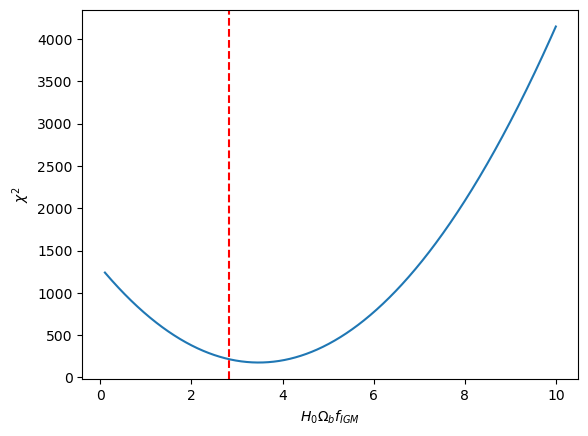

In [12]:
plt.plot(F_array, Chi)
plt.axvline(F_fid, color='r', linestyle='--')
plt.xlabel(r'$H_0 \Omega_b f_{IGM}$')
plt.ylabel(r'$\chi^2$')
plt.show()

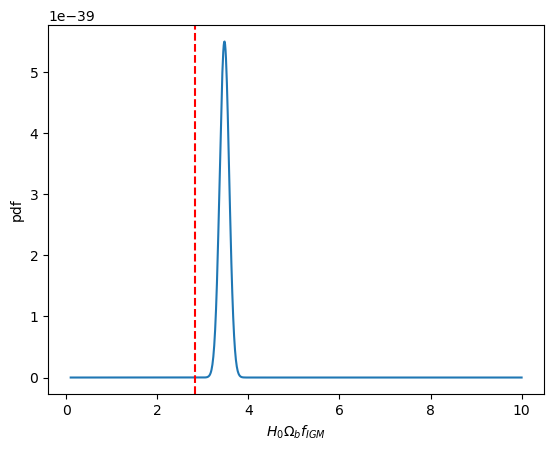

In [13]:
plt.plot(F_array, np.exp(-Chi/2))
plt.axvline(F_fid, color='r', linestyle='--')
plt.xlabel(r'$H_0 \Omega_b f_{IGM}$')
plt.ylabel(r'pdf')
plt.show()

## Macquart. 2020 reproduce

$$ DM=DM_{MW, ISM}+DM_{MW, halo}+DM_{cosmic, IGM}+DM_{host}$$

$ DM_{halo}\approx 50 pc\,cm^{-3} $

$ DM_{MW, ISM}=30 pc\,cm^{-3} $ high Galactic latitudes

$ p_{host}(DM_{host}|\mu,\sigma_{host})=\frac{1}{\sqrt{2\pi}DM \sigma_{host}}\exp\left[-\frac{(\log DM-\mu)^2}{2\sigma_{host}^2}\right] $

median value of $ \exp^\mu$ and variance $ \exp\{(\mu+\sigma_{host}^2)/2\} (\exp\{\sigma_{host}^2\}-1)^{1/2} $

Note $ DM_{host}/(1+z) $

In [14]:
def pdf_DM_host(DM, e_mu, sigma_host):
    # e^\mu with 20-200 pc cm^{-3} and \sigma_{host} in 0.2-2.0
    mu=np.log(e_mu)
    pdf=np.exp(-(np.log(DM)-mu)**2/(2*sigma_host**2))/(sigma_host*np.sqrt(2*np.pi)*DM)
    
    return pdf

/var/folders/9w/bbgy16c17_g3tqprqy1t6jcr0000gn/T/ipykernel_59900/1460587641.py:4: RuntimeWarning: divide by zero encountered in log
  pdf=np.exp(-(np.log(DM)-mu)**2/(2*sigma_host**2))/(sigma_host*np.sqrt(2*np.pi)*DM)
/var/folders/9w/bbgy16c17_g3tqprqy1t6jcr0000gn/T/ipykernel_59900/1460587641.py:4: RuntimeWarning: invalid value encountered in true_divide
  pdf=np.exp(-(np.log(DM)-mu)**2/(2*sigma_host**2))/(sigma_host*np.sqrt(2*np.pi)*DM)


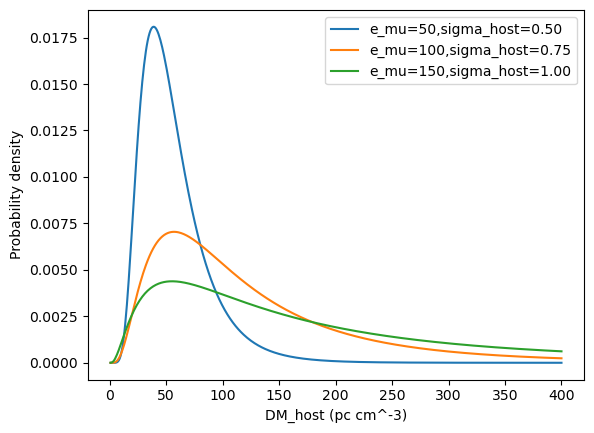

In [15]:
DM_host=np.linspace(0,400,500)
p1=pdf_DM_host(DM_host,e_mu=50,sigma_host=0.50)
p2=pdf_DM_host(DM_host,e_mu=100,sigma_host=0.75)
p3=pdf_DM_host(DM_host,e_mu=150,sigma_host=1.00)

plt.plot(DM_host,p1,label='e_mu=50,sigma_host=0.50')
plt.plot(DM_host,p2,label='e_mu=100,sigma_host=0.75')
plt.plot(DM_host,p3,label='e_mu=150,sigma_host=1.00')
plt.xlabel('DM_host (pc cm^-3)')
plt.ylabel('Probability density')
plt.legend()
plt.show()

$ p_{cosmic, IGM}(\Delta)=A\Delta^{-\beta}\exp\left(-\frac{(\Delta^{-\alpha}-C_0)^2}{2\alpha^2 \sigma_{DM}^2}\right) $

$ \sigma_{DM} $ dominated by physical variance in $DM_{cosmic}$

$\Delta=DM_{cosmic}/<DM_{cosmic}>$

$ \sigma_{DM}=Fz^{-0.5} $

Whith 3D density profile scales as $ \rho \propto r^{-\alpha} $, we have $\beta=(\alpha+1)/(\alpha-1)$

$ \alpha=3$, $\beta=3$

In [9]:
def f_sigma_DM(F, z):
    return F*z**-0.5

def pdf_DM_cosmo(DM, C_0, A, F, z, alpha=3):
    beta= alpha#(alpha+1)/(alpha-1)
    sigma_DM=f_sigma_DM(F, z)
    pdf=A*DM**(-beta)*np.exp(-(DM**(-alpha)-C_0)**2/(2*alpha**2*sigma_DM**2))
    return pdf

In [3]:
print(2**3*-3)
print(f_sigma_DM(F=1,z=9))

-24
0.3333333333333333


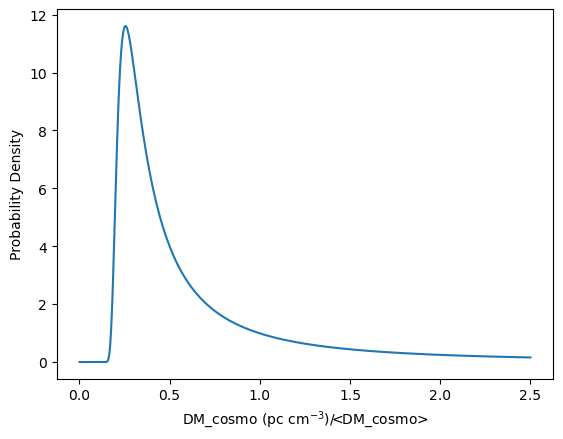

In [4]:
DM_cos=np.linspace(0.001,2.5,1000)
p=pdf_DM_cosmo(DM_cos, C_0=10, A=1, F=10, z=0.2)
plt.plot(DM_cos,p)
plt.xlabel('DM_cosmo (pc cm$^{-3}$)/<DM_cosmo>')
plt.ylabel('Probability Density')
plt.show()

Two constants still not known: $A $ and $ C_0$. According to the paper, $ C_0$ is constrain by the $ <x>=\int xp dx=1$. considering pdf, we also have $ \int p dx=1$, which help us to find $ C_0$ and $A$.

$ \int p_{cosmic, IGM}(x) dx=\int A x^{-\beta}\exp\left(-\frac{(x^{-\alpha}-C_0)^2}{2\alpha^2 \sigma_{DM}^2}\right)dx=1 $

$ \int x p_{cosmic, IGM}(x) dx=\int A x^{-\beta+1}\exp\left(-\frac{(x^{-\alpha}-C_0)^2}{2\alpha^2 \sigma_{DM}^2}\right)dx=1 $

When we do:

$ \frac{\int x p_{cosmic, IGM}(x) dx}{\int p_{cosmic, IGM}(x) dx}=\frac{\int A x^{-\beta+1}\exp\left(-\frac{(x^{-\alpha}-C_0)^2}{2\alpha^2 \sigma_{DM}^2}\right)dx}{\int A x^{-\beta}\exp\left(-\frac{(x^{-\alpha}-C_0)^2}{2\alpha^2 \sigma_{DM}^2}\right)dx}=1 $

Equavalent to: 

$ \int x \cdot p_{cosmic, IGM}(x) dx - \int p_{cosmic, IGM}(x) dx=0 $

Using this equation to do numerical calculation.

If use $ \int (x-1) p_{cosmic, IGM}(x) dx=0 $ to find C_0 will cost more time.

$A$ cancels out so we can solve for $C_0$. As for $A$, when we have $C_0$,we have:

$ A=\frac{A}{\int p_{cosmic, IGM}(x) dx}=\frac{1}{\int x^{-\beta}\exp\left(-\frac{(x^{-\alpha}-C_0)^2}{2\alpha^2 \sigma_{DM}^2}\right)dx} $

First, let's find $C_0$

In [ ]:
from scipy.integrate import quad_vec

# def x_pdf_DM_cosmo(DM, C_0, A, F, z, alpha=3):
#     beta= alpha #(alpha+1)/(alpha-1)
#     sigma_DM=f_sigma_DM(F, z)
#     pdf=A*DM**(1-beta)*np.exp(-(DM**(-alpha)-C_0)**2/(2*alpha**2*sigma_DM**2))
    
#     return pdf

# def to_C_0(C_0, F, z, alpha=3):
#     #result, error = quad(integrand, 0, np.inf, args=(A, beta, alpha, C0, sigma_DM))
#     A=1
#     x_pdf, error = quad_vec(lambda x: x_pdf_DM_cosmo(x, C_0, A, F, z, alpha), 0, np.inf)
#     pdf, error = quad_vec(lambda x: pdf_DM_cosmo(x, C_0, A, F, z, alpha), 0, np.inf)
#     #print(f'x_pdf={x_pdf},pdf={pdf}')
#     try:
#         ratio=x_pdf/pdf
#     except ZeroDivisionError:
#         print(f'zero division error for x_pdf={x_pdf},pdf={pdf}')
#         ratio=50
#     except Exception as e:
#         print(f'unknown error for x_pdf={x_pdf},pdf={pdf},error={e}')
#     return ratio

# vec_C_0=np.vectorize(to_C_0)

In [ ]:
# print(to_C_0(C_0=45,F=0.5,z=0.9))

nan


C:\Users\klera\AppData\Local\Temp\ipykernel_8136\2842847393.py:17: RuntimeWarning: invalid value encountered in double_scalars
  ratio=x_pdf/pdf


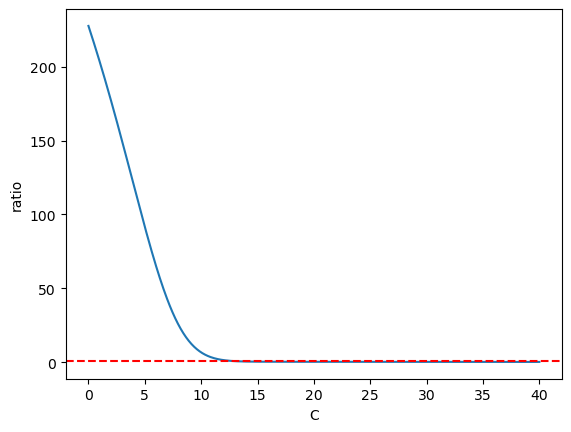

In [ ]:
# C=np.linspace(0.001,40,500)
# ratio=vec_C_0(C,F=0.5, z=0.2)
# plt.plot(C,ratio)
# plt.axhline(1,color='r',ls='--')
# plt.xlabel('C')
# plt.ylabel('ratio')
# plt.show()

In [71]:
from scipy.optimize import fsolve

def find_C0(F, z, alpha=3, initial_guess=1.0):
    """
    Use fsolve to find C_0 when to_C_0 = 1
    
    Parameters:
    -----------
    F: float - Structure factor parameter 
    z: float - Redshift
    alpha: float - Alpha parameter
    initial_guess: float - C_0 initial guess
    
    Returns:
    --------
    float: C_0 or None if solution not found
    """
    
    def objective_function(C_0):
        #return to_C_0(C_0[0], F, z, alpha) - 1
        A=1
        result1,_= quad(lambda x: x*pdf_DM_cosmo(x, C_0, A, F, z, alpha=3), 0, np.inf)
        result2,_= quad(lambda x: pdf_DM_cosmo(x, C_0, A, F, z, alpha=3), 0, np.inf)
        return result1-result2
    
    try:
        solution = fsolve(objective_function, [initial_guess], full_output=True)
        
        if solution[2] == 1:  # Check if solution is found
            return solution[0][0]
        else:
            print(f"find_C0 warning: F={F}, z={z}")
            return None
            
    except Exception as e:
        print(f"find_C0 error, F={F}, z={z}, error: {e}")
        return None

# Example usage
Fs = np.linspace(0.01, 0.5,10)
results = {}

for F in Fs:
    C_0 = find_C0(F=F, z=0.2)
    results[F] = C_0
    print(f"For F = {F}: C_0 = {C_0}")

For F = 0.01: C_0 = 1.0045183164070408
For F = 0.06444444444444444: C_0 = 1.2461762326530976
For F = 0.11888888888888888: C_0 = 1.6727084195353494
For F = 0.17333333333333334: C_0 = 2.0110568510984317
For F = 0.22777777777777777: C_0 = 2.2598800748232577
For F = 0.2822222222222222: C_0 = 2.4302562360462345
For F = 0.33666666666666667: C_0 = 2.530641233199334
For F = 0.3911111111111111: C_0 = 2.5672039996359968
For F = 0.44555555555555554: C_0 = 2.544560414160758
For F = 0.5: C_0 = 2.466268439524445


In [72]:
import timeit

In [73]:
print("\n Timing for Jiaming:")
%timeit find_C0(F=0.1, z=1)


 Timing for Jiaming:
24.3 ms ± 192 µs per loop (mean ± std. dev. of 7 runs, 10 loops each)


cross check

In [74]:
zs = np.linspace(0.001, 2, 100)
C_0_z = pd.DataFrame(zs, columns=['z'])

for i, z in enumerate(zs):
    C_0 = find_C0(F=0.1, z=z)
    C_0_z.loc[i, 'C_0'] = C_0
C_0_z.head()

,z,C_0
0,0.001000,-5.658269
1,0.021192,2.484595
2,0.041384,2.228710
3,0.061576,2.047243
4,0.081768,1.915944


In [75]:
C_0_z.to_csv('C_0_z_v2.csv')

Now let's try to find $A$

In [76]:
def find_A(C_0, F, z, alpha=3):
    pdf, error = quad(lambda x: pdf_DM_cosmo(x, C_0, 1, F, z, alpha), 0, np.inf)
    
    try:
        return 1/pdf
            
    except Exception as e:
        print(f"find_A error，pdf={pdf}, C_0={C_0}, F={F}, z={z}, error: {e}")
        return None

Check if correct

In [78]:
z=0.2
F=0.3

C_0=find_C0(F=F,z=z)
A=find_A(C_0=C_0,F=F,z=z)
print(fr'C_0={C_0}, A={A}')

pdf,error=quad(lambda x: pdf_DM_cosmo(x, C_0, A, F, z), 0, np.inf)
print(pdf,error)

C_0=2.4703923346339303, A=0.8281161404473844
0.9999999999999998 2.5107740454965393e-09


Show extend fig. 3. Double check.

In [79]:
DMs=np.linspace(40,1100,1000)
zs=np.array([0.1,0.2,0.5,1.0])
p_DM=pd.DataFrame(columns=zs)
F=0.15
vec_DM_cosmo=np.vectorize(pdf_DM_cosmo)

for z in zs:
    C_0=find_C0(F=F,z=z)
    A=find_A(C_0=C_0,F=F,z=z)
    DM_mean=dispersion_measure(z=z,H0=HUBBLE,Om=OMEGA_MATTER) # need larger
    p_DM[z]=DMs*vec_DM_cosmo(DM=DMs/DM_mean,A=A,z=z,C_0=C_0,F=F)

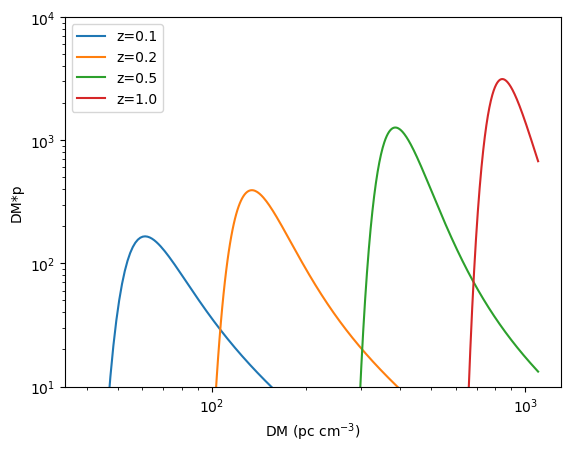

In [80]:
plt.plot(DMs,p_DM[zs[0]],label='z=0.1')
plt.plot(DMs,p_DM[zs[1]],label='z=0.2')
plt.plot(DMs,p_DM[zs[2]],label='z=0.5')
plt.plot(DMs,p_DM[zs[3]],label='z=1.0')
plt.xlabel('DM (pc cm$^{-3}$)')
plt.ylabel('DM*p')
plt.xscale('log')
plt.yscale('log')
plt.ylim(10, 10**4)
plt.legend()
plt.show()

Now let's try to find best parameters for FRBs.

No rows with DM_ < 0 found to drop


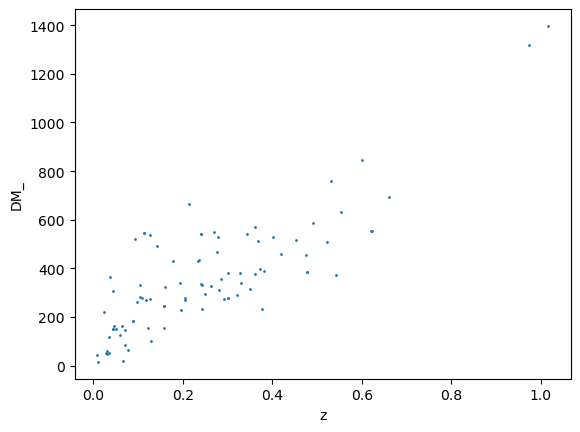

In [81]:
DM_halo=30  # In paper is 50, but Bing suggest smaller values
# DM_ISM=30 # we already have DM_MW in data

data['DM_']=data['DM_ext']-DM_halo

dropped_rows = data[data['DM_'] < 0]

# 2. Print FRB values of dropped rows if any exist
if not dropped_rows.empty:
    print("Dropped rows:")
    print(dropped_rows[['FRB', 'DM_']])
else:
    print("No rows with DM_ < 0 found to drop")

# 3. Keep only rows where DM_ext >= 0
data = data[data['DM_'] >= 0]

plt.scatter(data['z'],data['DM_'],s=1)
plt.ylabel('DM_')
plt.xlabel('z')
plt.show()

In [82]:
data.head()

,FRB,DM_ext,z,DM_
0,FRB 20121102A,369.00,0.19273,339.00
1,FRB 20171020A,76.10,0.00860,46.10
2,FRB 20180301A,370.00,0.33040,340.00
3,FRB 20180916B,149.30,0.03370,119.30
4,FRB 20180924B,320.92,0.32140,290.92


$ DM'_{FRB}=DM_{FRB}-DM_{MW, ISM}-DM_{MW, halo}=DM_{host}+DM_{cosmic} $

$ P_i(DM'_{FRB,i}|z_i)=\int_0^{DM'_{FRB,i}} p_{host}(DM_{host}|\mu, \sigma_{host})p_{cosmic}(DM'_{FRB,i}-DM_{host}, z_i)d DM_{host}$

$ \mathcal{L} = \prod_{i=1}^{N_{\text{FRBs}}} P_i(\text{DM}'_{\text{FRB}} | z_i) $


Note actually:

$ DM'_{FRB}=DM_{FRB}-DM_{MW, ISM}-DM_{MW, halo}=\frac{DM_{host}}{1+z}+DM_{cosmic} $

so:

$ P_i(DM'_{FRB,i}|z_i)=\int_0^{DM'_{FRB,i}} p_{host}(DM_{host}|\mu, \sigma_{host})p_{cosmic}(DM'_{FRB,i}-\frac{DM_{host}}{1+z_i}, z_i)d DM_{host}$

In [83]:
def DM_IGM_O_bh_70(z, O_bh_70, Om=OMEGA_MATTER ,w=-1):
    """
    Function of the DM formula, 
    eq. (12) in [arXiv:1805.12265].
    
    Input
    ----------
    z : redshift
    
    H0 : Hubble constant [km/s/Mpc]
    
    Om : Omega matter
    
    w : DE EoS parameter (w=-1 for Λ)
    
    Output
    ---------
    DM : Dispersion measure [pc/cm^3]
    """    
    
    O_bH_0=O_bh_70*70

    factor = 3*C_LIGHT*KM_2_MPC*O_bH_0*f_IGM/(8*PI*G_NEWTON*M_PROTON)*(7/8)
    integral = quad(dDM_integrand_w, 0, z, args=(Om, w))[0]
    
    unit_transform = DM_2_PCCM3
    
    DM = unit_transform*factor*integral
    
    return DM

In [84]:
def calculate_dm_probability(DM_frb,z,F,O_bh_70,sigma_host,e_mu):
    """
    Calculate the probability of DM_FRB given various cosmological parameters
    
    Parameters:
    -----------
    DM_frb : float
        The observed DM_FRB value
    z : float
        Redshift
    F : float
        Structure factor parameter
    O_bh_70 : float
        Baryon density parameter
    sigma_host : float
        Standard deviation of host DM distribution
    e_mu : float
        Mean of host DM distribution
    
    Returns:
    --------
    float
        The calculated probability
    """

    def integrand(DM_host):
        # Calculate p_host at the current dm_host value
        p_host_val = pdf_DM_host(DM_host, e_mu, sigma_host)
        
        # Calculate p_cosmic at (DM_FRB - DM_host)
        C_0=find_C0(F=F, z=z)
        
        if C_0 is None:
            print(f"Error: find_C0 C_0 is None, when F={F}, z={z}")
            return 0.0
            
        try:
            A = find_A(C_0=C_0, F=F, z=z)
        except:
            print(f"Error: find_A, when F={F}, z={z}")
            return 0.0
        
        if A is None:
            print(f"Error: C_0={C_0} or A={A}, when F={F}, z={z}")
            return 0.0
        
        # Calculate delta parameter
        delta=DM_frb - DM_host/(1+z)
        delta=delta/DM_IGM_O_bh_70(z=z,O_bh_70=O_bh_70)
        p_cosmic_val = pdf_DM_cosmo(DM=delta, C_0=C_0, A=A, F=F,z=z)
        
        return p_host_val * p_cosmic_val
    
    # Perform the integration from 0 to DM_FRB
    result, error = quad_vec(integrand, 0, DM_frb)
    
    return result

In [85]:
F_array=np.linspace(0.01,0.5,20)
O_bh_70_array=np.linspace(0.015,0.095,10)
sigma_host_array=np.linspace(0.2,2.0,10)
e_mu_array=np.linspace(20,200,100)

F_4D, O_bh_70_4D, sigma_host_4D, e_mu_4D = np.meshgrid(F_array, O_bh_70_array, sigma_host_array, e_mu_array)

F_h, h_F = np.meshgrid(F_array, O_bh_70_array)
F_sigma, sigma_F = np.meshgrid(F_array, sigma_host_array)
F_e_mu, e_mu_F = np.meshgrid(F_array, e_mu_array)

h_sigma, sigma_h = np.meshgrid(O_bh_70_array, sigma_host_array)
h_e_mu, e_mu_h = np.meshgrid(O_bh_70_array, e_mu_array)

sigma_e_mu, e_mu_sigma = np.meshgrid(sigma_host_array, e_mu_array)

print(fr'Shape of F_4D: {F_4D.shape}, O_bh_70_4D: {O_bh_70_4D.shape}, sigma_host_4D: {sigma_host_4D.shape}, e_mu_4D: {e_mu_4D.shape}')
print(fr'Shape of F_h: {F_h.shape}, h_F: {h_F.shape}, F_sigma: {F_sigma.shape}, sigma_F: {sigma_F.shape}, F_e_mu: {F_e_mu.shape}, e_mu_F: {e_mu_F.shape}')

Shape of F_4D: (10, 20, 10, 100), O_bh_70_4D: (10, 20, 10, 100), sigma_host_4D: (10, 20, 10, 100), e_mu_4D: (10, 20, 10, 100)
Shape of F_h: (10, 20), h_F: (10, 20), F_sigma: (10, 20), sigma_F: (10, 20), F_e_mu: (100, 20), e_mu_F: (100, 20)


In [86]:
print(calculate_dm_probability(DM_frb=300,z=0.2,F=0.1,O_bh_70=0.05,sigma_host=0.25,e_mu=50))

0.14440497809601602


In [87]:
import timeit

def timer_calculate_dm_probability():
    return calculate_dm_probability(DM_frb=300, z=0.2, F=0.1, O_bh_70=0.05, sigma_host=0.25, e_mu=50)

# 测量执行时间
execution_time = timeit.timeit(timer_calculate_dm_probability, number=1)
print(f"calculate_dm_probability time: {execution_time:.6f} seconds")

calculate_dm_probability time: 5.428710 seconds


In [33]:
# # Initialize posterior_4D array for storing results
# posterior_4D = np.zeros_like(F_4D)

# # Iterate through all parameter combinations
# for i, F in enumerate(F_array):
#     for j, O_bh70 in enumerate(O_bh_70_array):
#         for k, sigma_host in enumerate(sigma_host_array):
#             for l, e_mu in enumerate(e_mu_array):
#                 # Initialize the total probability for current parameter combination
#                 prob_total = 1.0  # or 0.0 if you want to sum instead of multiply
#                
#                 # Calculate and accumulate probabilities for each FRB
#                 for _, row in data.iterrows():
#                     prob = calculate_dm_probability(
#                         DM_frb=row['DM_'],     # Use DM_ column as DM_frb
#                         z=row['z'],            # Use z column as redshift
#                         F=F,                   # Structure factor from parameter space
#                         O_bh_70=O_bh70,        # Baryon density from parameter space
#                         sigma_host=sigma_host, # Host DM standard deviation from parameter space
#                         e_mu=e_mu             # Host DM mean from parameter space
#                     )
#                     # Accumulate probability (multiply or add)
#                     prob_total *= prob  # or prob_total += prob
                
#                 # Store the accumulated result in posterior_4D
#                 posterior_4D[i,j,k,l] = prob_total
                
#             print(f"i,j,k,l = {i},{j},{k},{l}",end='\r')

Understand PDF, CDF, PPF for chi2

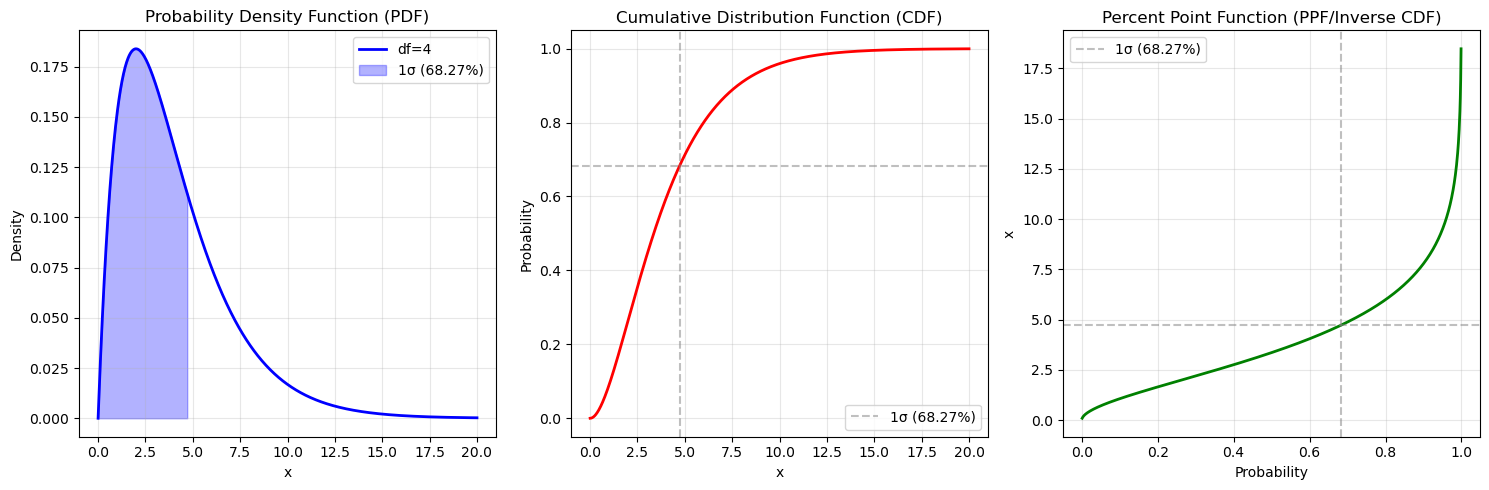


Critical values for different sigma levels (df=4):
1σ (68.27%): 4.720
2σ (95.45%): 9.716
3σ (99.73%): 16.251


In [34]:
from scipy import stats

# Create figure with three subplots
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))

# Generate x values for plotting
x = np.linspace(0, 20, 1000)
p = np.linspace(0.001, 0.999, 1000)  # for PPF, avoid 0 and 1

# Plot PDF (Probability Density Function)
df = 4  # degrees of freedom
pdf = stats.chi2.pdf(x, df)
ax1.plot(x, pdf, 'b-', lw=2, label=f'df={df}')
ax1.fill_between(x, pdf, where=(x <= stats.chi2.ppf(0.6827, df)), 
                 alpha=0.3, color='blue', label='1σ (68.27%)')
ax1.set_title('Probability Density Function (PDF)')
ax1.set_xlabel('x')
ax1.set_ylabel('Density')
ax1.grid(True, alpha=0.3)
ax1.legend()

# Plot CDF (Cumulative Distribution Function)
cdf = stats.chi2.cdf(x, df)
ax2.plot(x, cdf, 'r-', lw=2)
ax2.axhline(y=0.6827, color='gray', linestyle='--', alpha=0.5, label='1σ (68.27%)')
ax2.axvline(x=stats.chi2.ppf(0.6827, df), color='gray', linestyle='--', alpha=0.5)
ax2.set_title('Cumulative Distribution Function (CDF)')
ax2.set_xlabel('x')
ax2.set_ylabel('Probability')
ax2.grid(True, alpha=0.3)
ax2.legend()

# Plot PPF (Percent Point Function / Inverse CDF)
ppf = stats.chi2.ppf(p, df)
ax3.plot(p, ppf, 'g-', lw=2)
ax3.axvline(x=0.6827, color='gray', linestyle='--', alpha=0.5, label='1σ (68.27%)')
ax3.axhline(y=stats.chi2.ppf(0.6827, df), color='gray', linestyle='--', alpha=0.5)
ax3.set_title('Percent Point Function (PPF/Inverse CDF)')
ax3.set_xlabel('Probability')
ax3.set_ylabel('x')
ax3.grid(True, alpha=0.3)
ax3.legend()

# Adjust layout
plt.tight_layout()
plt.show()

# Print some key values
sigma_levels = [0.6827, 0.9545, 0.9973]  # 1σ, 2σ, 3σ
print("\nCritical values for different sigma levels (df=4):")
for i, level in enumerate(sigma_levels, 1):
    critical_value = stats.chi2.ppf(level, df)
    print(f"{i}σ ({level*100:.2f}%): {critical_value:.3f}")

Draw contour plot, based on AI answer. 

In [35]:
# from scipy import stats

# def calculate_D(posterior_4D):
#     """
#     Calculate likelihood ratio test statistic D
    
#     Parameters:
#     -----------
#     posterior_4D : numpy.ndarray
#         4D array containing likelihood values (L in the equation)
    
#     Returns:
#     --------
#     D_4D : numpy.ndarray
#         4D array containing D statistic values calculated as -2ln(L/L_max)
#     """
#     L_max = np.max(posterior_4D)
#     D_4D = -2 * (np.log(posterior_4D) - np.log(L_max))
#     return D_4D

# def get_sigma_thresholds():
#     """
#     Calculate threshold values for 1σ, 2σ, and 3σ confidence levels using chi-square distribution
    
#     Returns:
#     --------
#     list
#         Three threshold values corresponding to:
#         1σ (68.27%), 2σ (95.45%), 3σ (99.73%) confidence levels
#     """
#     confidence_levels = [0.6827, 0.9545, 0.9973]
#     thresholds = [stats.chi2.ppf(cl, df=4) for cl in confidence_levels]
#     return thresholds

# def plot_contours(D_4D, param1_grid, param2_grid, param1_name, param2_name, 
#                  param_indices):
#     """
#     Plot 2D contours showing 1σ, 2σ, and 3σ confidence regions for given parameters
    
#     Parameters:
#     -----------
#     D_4D : numpy.ndarray
#         4D array of D statistic values
#     param1_grid, param2_grid : numpy.ndarray
#         2D meshgrid arrays for the two parameters to plot
#     param1_name, param2_name : str
#         Names of parameters for axis labels
#     param_indices : tuple
#         Indices of the two parameters in the original 4D array (0-based)
#         These indices determine which dimensions to marginalize over
#     """
#     # Determine which dimensions need to be marginalized
#     all_dims = set(range(4))
#     plot_dims = set(param_indices)
#     marginalize_dims = tuple(all_dims - plot_dims)
    
#     # Marginalize over other dimensions by taking the minimum D value
#     # This effectively finds the best-fit values for the marginalized parameters
#     D_2D = np.min(D_4D, axis=marginalize_dims)
    
#     # Transpose D_2D if necessary to match the parameter grid orientations
#     # This ensures the axes of D_2D match the orientations of param1_grid and param2_grid
#     if param_indices[0] > param_indices[1]:
#         D_2D = D_2D.T
    
#     # Get thresholds for different sigma levels
#     thresholds = get_sigma_thresholds()
    
#     # Create the figure
#     plt.figure(figsize=(8, 6))
    
#     # Plot filled contours for each confidence level
#     colors = ['lightblue', 'lightgreen', 'pink']
#     labels = ['1σ (68.27%)', '2σ (95.45%)', '3σ (99.73%)']
    
#     for i, (threshold, color, label) in enumerate(zip(thresholds, colors, labels)):
#         # Draw contour lines with different line styles
#         plt.contour(param1_grid, param2_grid, D_2D, levels=[threshold], 
#                    colors='k', linestyles=['-', '--', ':'][i])
#         # Fill regions within contours
#         plt.contourf(param1_grid, param2_grid, D_2D, levels=[0, threshold],
#                     colors=[color], alpha=0.3, label=label)
    
#     plt.xlabel(param1_name)
#     plt.ylabel(param2_name)
#     plt.title('Confidence Regions (1σ, 2σ, 3σ)')
#     plt.legend()

# # Define parameter order in the 4D array
# # This maps parameter names to their corresponding indices in D_4D
# PARAM_ORDER = {
#     'F': 0,
#     'Ω_bh_70': 1,
#     'σ_host': 2,
#     'μ': 3
# }

# # Main execution code
# D_4D = calculate_D(posterior_4D)

# # Define parameter pairs to plot with their corresponding indices
# parameter_pairs = [
#     # (param1_grid, param2_grid, param1_name, param2_name, (param1_index, param2_index))
#     (F_h, h_F, 'F', 'Ω_bh_70', (PARAM_ORDER['F'], PARAM_ORDER['Ω_bh_70'])),
#     (F_sigma, sigma_F, 'F', 'σ_host', (PARAM_ORDER['F'], PARAM_ORDER['σ_host'])),
#     (F_e_mu, e_mu_F, 'F', 'μ', (PARAM_ORDER['F'], PARAM_ORDER['μ'])),
#     (h_sigma, sigma_h, 'Ω_bh_70', 'σ_host', (PARAM_ORDER['Ω_bh_70'], PARAM_ORDER['σ_host'])),
#     (h_e_mu, e_mu_h, 'Ω_bh_70', 'μ', (PARAM_ORDER['Ω_bh_70'], PARAM_ORDER['μ'])),
#     (sigma_e_mu, e_mu_sigma, 'σ_host', 'μ', (PARAM_ORDER['σ_host'], PARAM_ORDER['μ']))
# ]

# # Plot all parameter combinations
# for param1_grid, param2_grid, param1_name, param2_name, param_indices in parameter_pairs:
#     plot_contours(D_4D, param1_grid, param2_grid, param1_name, param2_name, param_indices)
#     plt.show()

# MCMC method

not finish run yet

In [36]:
# Check your data structure
print("Data shape:", data.shape)
print("Data columns:", data.columns)
print("First few rows:")
print(data.head())

# Check for any missing values
print("\nMissing values:")
print(data.isnull().sum())

Data shape: (91, 4)
Data columns: Index(['FRB', 'DM_ext', 'z', 'DM_'], dtype='object')
First few rows:
             FRB  DM_ext        z     DM_
0  FRB 20121102A  369.00  0.19273  339.00
1  FRB 20171020A   76.10  0.00860   46.10
2  FRB 20180301A  370.00  0.33040  340.00
3  FRB 20180916B  149.30  0.03370  119.30
4  FRB 20180924B  320.92  0.32140  290.92

Missing values:
FRB       0
DM_ext    0
z         0
DM_       0
dtype: int64


In [37]:
import numpy as np
import emcee

def log_probability(theta, data, calculate_dm_probability):
    """
    Calculate log probability for the MCMC sampler
    
    Parameters:
    theta : array-like
        Contains [F, O_bh70, sigma_host, e_mu]
    data : pandas DataFrame
        Contains FRB data with DM_ and z columns
    calculate_dm_probability : function
        Function to calculate DM probability
    """
    # Unpack parameters
    F, O_bh70, sigma_host, e_mu = theta
    
    # Prior bounds
    if not (0 < F < 1 and        # Adjust these bounds based on your needs
            0 < O_bh70 < 1 and 
            0 < sigma_host < 1000 and 
            0 < e_mu < 1000):
        return -np.inf
    
    # Calculate log probability
    log_prob = 0.0
    
    # Calculate probability for each FRB
    for _, row in data.iterrows():
        prob = calculate_dm_probability(
            DM_frb=float(row['DM_']),
            z=float(row['z']),
            F=float(F),
            O_bh_70=float(O_bh70),
            sigma_host=float(sigma_host),
            e_mu=float(e_mu)
        )
        
        # Add log probability (equivalent to multiplying probabilities)
        if prob > 0:  # Avoid log(0)
            log_prob += np.log(prob)
        else:
            return -np.inf
            
    return log_prob

def run_mcmc(data, calculate_dm_probability, n_walkers=32, n_steps=10000):
    """
    Run MCMC sampling
    
    Parameters:
    data : pandas DataFrame
        Contains FRB data
    calculate_dm_probability : function
        Function to calculate DM probability
    n_walkers : int
        Number of walkers
    n_steps : int
        Number of steps per walker
    """
    # Number of parameters
    n_dim = 4
    
    # Initial positions for walkers (adjust ranges based on your needs)
    initial_F = np.random.uniform(0.1, 0.9, n_walkers)
    initial_O_bh70 = np.random.uniform(0.1, 0.9, n_walkers)
    initial_sigma_host = np.random.uniform(10, 100, n_walkers)
    initial_e_mu = np.random.uniform(10, 100, n_walkers)
    
    initial_pos = np.column_stack([initial_F, initial_O_bh70, 
                                 initial_sigma_host, initial_e_mu])
    
    # Initialize sampler
    sampler = emcee.EnsembleSampler(
        n_walkers, n_dim, log_probability,
        args=(data, calculate_dm_probability)
    )
    
    # Run MCMC
    print("Starting MCMC sampling...")
    sampler.run_mcmc(initial_pos, n_steps, progress=True)
    
    return sampler

def analyze_chains(sampler, burnin=1000):
    """
    Analyze MCMC chains and return parameter estimates
    
    Parameters:
    sampler : emcee.EnsembleSampler
        The sampler after running MCMC
    burnin : int
        Number of steps to discard as burn-in
    """
    # Get samples and reshape
    samples = sampler.get_chain(discard=burnin, flat=True)
    
    # Calculate parameter estimates (median and 68% credible intervals)
    F_mcmc = np.percentile(samples[:, 0], [16, 50, 84])
    O_bh70_mcmc = np.percentile(samples[:, 1], [16, 50, 84])
    sigma_host_mcmc = np.percentile(samples[:, 2], [16, 50, 84])
    e_mu_mcmc = np.percentile(samples[:, 3], [16, 50, 84])
    
    return {
        'F': F_mcmc,
        'O_bh70': O_bh70_mcmc,
        'sigma_host': sigma_host_mcmc,
        'e_mu': e_mu_mcmc,
        'samples': samples
    }

In [38]:
# Example usage:

# Run the MCMC
sampler = run_mcmc(data, calculate_dm_probability)

# Analyze results
results = analyze_chains(sampler)

# Print results
params = ['F', 'O_bh70', 'sigma_host', 'e_mu']
for param, values in zip(params, results.items()):
    print(f"{param}: {values[1][1]:.3f} (+{values[1][2]-values[1][1]:.3f}, -{values[1][1]-values[1][0]:.3f})")

Starting MCMC sampling...
emcee: Exception while calling your likelihood function:
  params: [ 0.79257148  0.1073786  76.45568085 82.20793026]
  args: (              FRB   DM_ext        z      DM_
0   FRB 20121102A   369.00  0.19273   339.00
1   FRB 20171020A    76.10  0.00860    46.10
2   FRB 20180301A   370.00  0.33040   340.00
3   FRB 20180916B   149.30  0.03370   119.30
4   FRB 20180924B   320.92  0.32140   290.92
..            ...      ...      ...      ...
88  FRB 20230216A   788.00  0.53100   758.00
89  FRB 20221027A   405.00  0.54220   375.00
90  FRB 20221219A   662.00  0.55300   632.00
91  FRB 20221418A   585.00  0.62140   555.00
92  FRB 20221029A  1347.00  0.97500  1317.00

[91 rows x 4 columns], <function calculate_dm_probability at 0x12878c670>)
  kwargs: {}
  exception:


Traceback (most recent call last):
  File "/Users/zhuge/miniconda3/envs/py310/lib/python3.10/site-packages/emcee/ensemble.py", line 640, in __call__
    return self.f(x, *self.args, **self.kwargs)
  File "/var/folders/9w/bbgy16c17_g3tqprqy1t6jcr0000gn/T/ipykernel_86226/3075791350.py", line 31, in log_probability
    prob = calculate_dm_probability(
  File "/var/folders/9w/bbgy16c17_g3tqprqy1t6jcr0000gn/T/ipykernel_86226/2415999415.py", line 55, in calculate_dm_probability
    result, error = quad_vec(integrand, 0, DM_frb)
  File "/Users/zhuge/miniconda3/envs/py310/lib/python3.10/site-packages/scipy/integrate/_quad_vec.py", line 369, in quad_vec
    for dint, derr, dround_err, subint, dneval in mapwrapper(_subdivide_interval, to_process):
  File "/Users/zhuge/miniconda3/envs/py310/lib/python3.10/site-packages/scipy/integrate/_quad_vec.py", line 426, in _subdivide_interval
    s1, err1, round1 = _quadrature(a, c, f, norm_func)
  File "/Users/zhuge/miniconda3/envs/py310/lib/python3.10/sit

KeyboardInterrupt: 

In [48]:
def debug_calculation(data, F_val, O_bh_70_val, sigma_host_val, e_mu_val):
    """Test the calculation with specific values"""
    for i in range(len(data)):
        try:
            DM_frb = float(data.iloc[i]['DM_'])
            z = float(data.iloc[i]['z'])
            
            def integrand_MC(DM_host):
                p_host_val = pdf_DM_host(DM_host, e_mu_val, sigma_host_val)
                C_0 = find_C0(F=F_val, z=z)
                if C_0 is None:
                    return 0.0
                A = find_A(C_0=C_0, F=F_val, z=z)
                if A is None:
                    return 0.0
                delta = DM_frb - DM_host/(1+z)
                delta = delta/DM_IGM_O_bh_70(z=z, O_bh_70=O_bh_70_val)
                p_cosmic_val = pdf_DM_cosmo(DM=delta, C_0=C_0, A=A, F=F_val, z=z)
                return p_host_val * p_cosmic_val
            
            result, error = quad_vec(integrand_MC, 0, DM_frb)
            print(f"Data point {i}: result = {result}")
            
        except Exception as e:
            print(f"Error at data point {i}: {e}")

# Test with some initial values
debug_calculation(
    data,
    F_val=np.mean(F_array),
    O_bh_70_val=np.mean(O_bh_70_array),
    sigma_host_val=np.mean(sigma_host_array),
    e_mu_val=np.mean(e_mu_array)
)

Data point 0: result = 0.2067104707427456


KeyboardInterrupt: 

In [50]:
import pymc3 as pm
import theano.tensor as tt
import theano
from scipy.integrate import quad_vec
import numpy as np

# Define the model
with pm.Model() as model:
    # Define the parameters
    F = pm.Uniform('F', lower=min(F_array), upper=max(F_array))
    O_bh_70 = pm.Uniform('O_bh_70', lower=min(O_bh_70_array), upper=max(O_bh_70_array))
    sigma_host = pm.Uniform('sigma_host', lower=min(sigma_host_array), upper=max(sigma_host_array))
    e_mu = pm.Uniform('e_mu', lower=min(e_mu_array), upper=max(e_mu_array))
    
    def calculate_dm_probability_MC(DM_frb, z, F, O_bh_70, sigma_host, e_mu):
        """
        Calculate DM probability using Monte Carlo integration
        All inputs should be treated as Theano tensors
        """
        def wrapped_quad(DM_frb_val, z_val, F_val, O_bh_70_val, sigma_host_val, e_mu_val):
            def integrand_MC(DM_host):
                try:
                    # Calculate p_host
                    p_host_val = pdf_DM_host(DM_host, e_mu_val, sigma_host_val)
                    
                    # Calculate C_0
                    C_0 = find_C0(F=F_val, z=z_val)
                    if C_0 is None:
                        return 0.0
                        
                    # Calculate A
                    A = find_A(C_0=C_0, F=F_val, z=z_val)
                    if A is None:
                        return 0.0
                        
                    # Calculate delta
                    delta = DM_frb_val - DM_host/(1+z_val)
                    delta = delta/DM_IGM_O_bh_70(z=z_val, O_bh_70=O_bh_70_val)
                    
                    # Calculate p_cosmic
                    p_cosmic_val = pdf_DM_cosmo(
                        DM=delta, 
                        C_0=C_0, 
                        A=A, 
                        F=F_val, 
                        z=z_val
                    )
                    
                    return p_host_val * p_cosmic_val
                    
                except Exception as e:
                    print(f"Error in integrand: {e}")
                    return 0.0
            
            try:
                # Perform the integration
                result, error = quad_vec(integrand_MC, 0, DM_frb_val)
                return np.float64(result)
                
            except Exception as e:
                print(f"Error in integration: {e}")
                return np.float64(0.0)
        
        # Create a Theano operation
        result, _ = theano.scan(
            fn=wrapped_quad,
            sequences=[DM_frb, z],
            non_sequences=[F, O_bh_70, sigma_host, e_mu]
        )
        
        return result

    # Create observed data tensors
    DM_obs = tt.as_tensor_variable(data['DM_'].values.astype('float64'))
    z_obs = tt.as_tensor_variable(data['z'].values.astype('float64'))
    
    # Calculate likelihood
    likelihood = calculate_dm_probability_MC(
        DM_frb=DM_obs,
        z=z_obs,
        F=F,
        O_bh_70=O_bh_70,
        sigma_host=sigma_host,
        e_mu=e_mu
    )
    
    likelihood = tt.prod(likelihood)
    
    # Define the model
    pm.Deterministic('posterior_4D', likelihood)
    
    # Perform MCMC sampling with more conservative settings
    trace = pm.sample(
        draws=10000,
        chains=4,
        cores=4,
        tune=2000,
        target_accept=0.95,
        return_inferencedata=False
    )

# Analyze the results
print(pm.summary(trace))

# Plot the results
pm.plot_trace(trace)

Error in integration: float() argument must be a string or a real number, not 'TensorVariable'


ValueError: The return value of your scan lambda expression may only be made of lists, tuples, or dictionaries containing Theano variables (or `theano.scan.utils.until` objects for conditions). In particular if you need to use constant values, you can use `tensor.constant` to turn them into Theano variables.